## DevOps vs MLOps
- ML/LLM CI/CD add 3 extra gates
    - data validation
    - model evaluation
    - prompte quality chekcks
- Note: in traditional DevOPs mainly 2 gates
    - unit tests, and integration tests
- Skipping any gate will lead to a silent degration in production
- Traditinoal DevOps pipelines are code-centric; ML pipleines mus version **data, models, and prompts **
- Model performance can degrade without code change due to data drift

### DevOps vs MLOps vs LLMOps
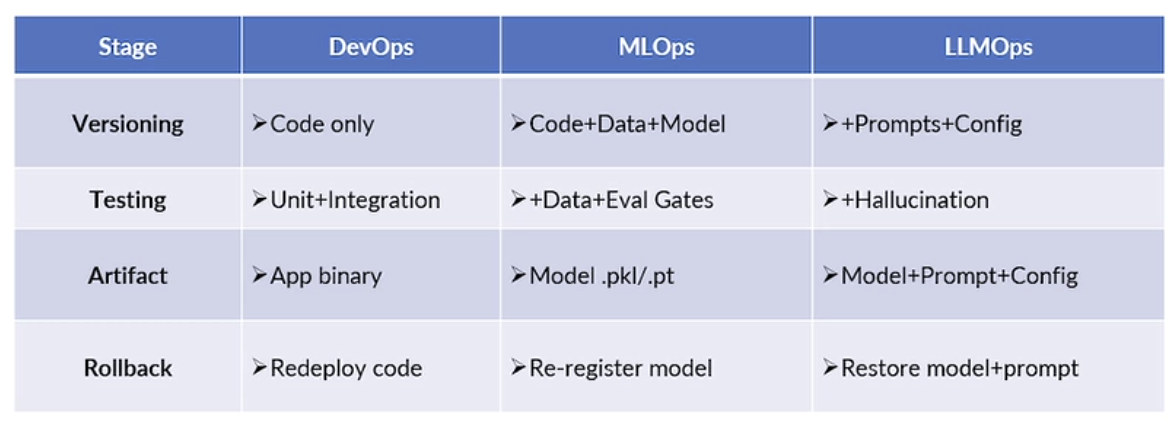

### 3 Silent Failurs when copying DevOps to ML
1. Unit test pass but data schema added a null column
2. Drift not caught - corrupted model trained on new null data
3. Model deployed - accuracy dorps 8% no alert triggered
- Fix: 3 Layer Pyramid: Unit Test -> Data Validation -> Eval Gate

### Why ML CI/CD is different?
- **Data is first class citizen**: model depends on both code and data quality
- **Non-dterministic behaviour**: same code can produce different result with different data
    - sampling
    - randomness
    - evolving data
- **Performance monitoring**: Accuracy/F1 metics are as critical as uptime
- **Gradual degration**: Models silently decaz over time due to data drift

### Real-wold example: Netflix Recommendation CI/CD
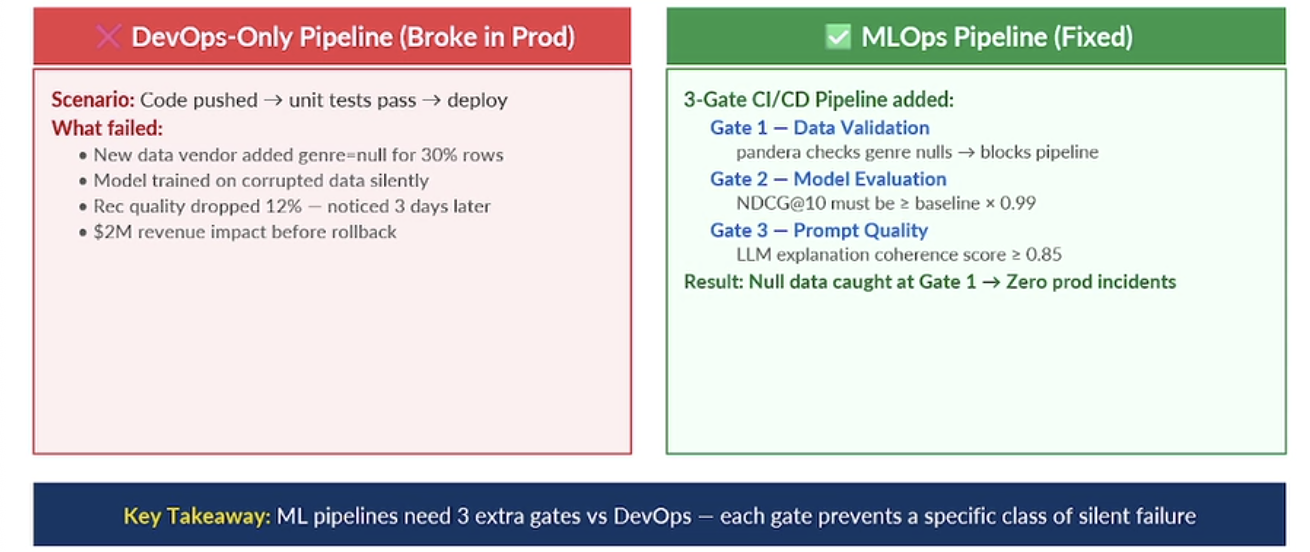

## Automating Build -> Test -> Deploy for ML Pipelines
### Pipeline Autiomation Principles
- Trigger types: push (dev), schedule (daily retrain), PR (eval before merge)
- Parellize gates: unit tests + data schema checks runs in parallel to save time
- Fail fast: data valiation fails -> tsop pipeline, don't waist compute on training
- Artifacts promotion: model only move staging -> Prod when all gates passed

### Daily retrain pipeline
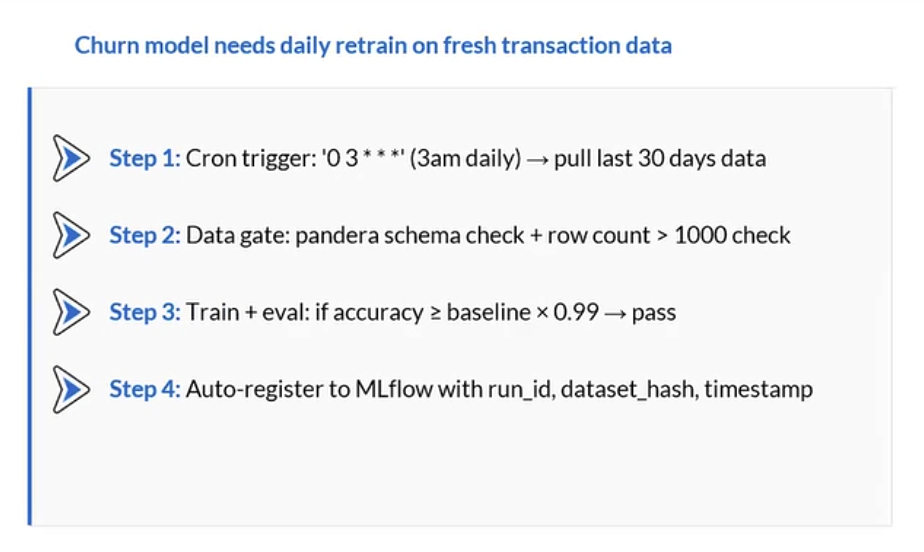

### Pipeline Best Practices
- Notification
    - Slack + email on gate failure with context (matric, threshold)
    - every satage logs results, errors and warnings
- Idempotency
    - Running pipeline with twice with same inputs produce same output
- Resource optimization
    - Use spot instances for training, reseved for inference
- Observability
    - Log all gates decisions, metrices and artifacts versions.

### Setting up scheduled retrain pipeline
- Key components of a GitHub Action schedule pipeline
    - Schedule trigger with crone expression for autiomated runs
    - Maual trigger (workflow_despatch) for on-demand execution
    - Sequential gates: data_pull -> validate -> train -> evaluate -> register
    - Enviroment variables for beaseline metrics and thresholds
    - Notification step using Slack/Teams webhook integration

### Full pipeline example: E-commerse churn model GitHub Action
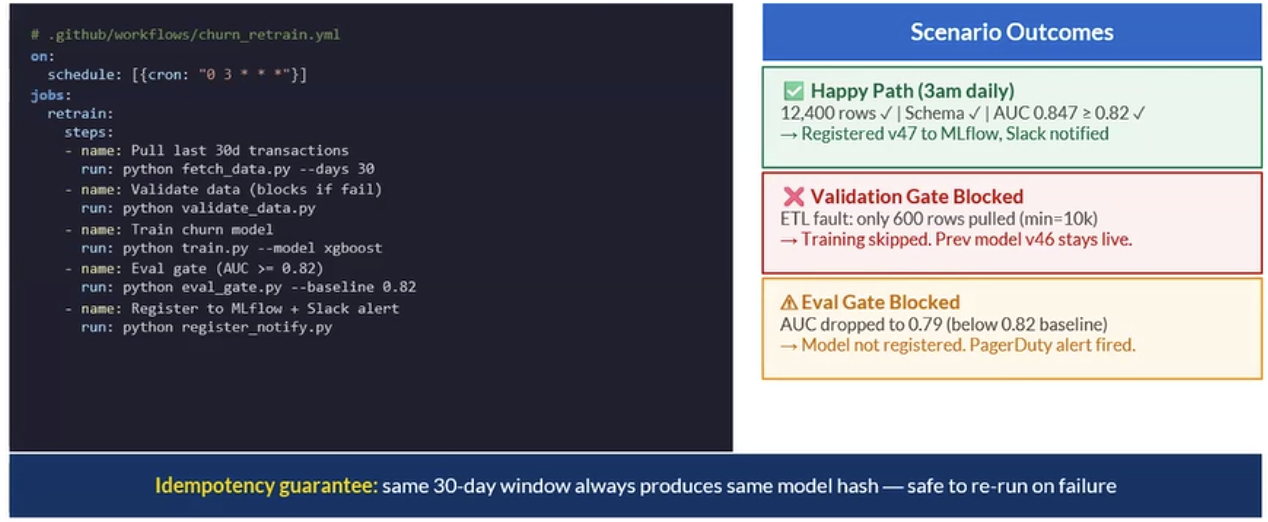
